# Project: ML model comparison on Breast Cancer dataset

## Setup

### Data

We use the Breast Cancer Dataset:

In [86]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

PLOT_CONFIG = {
    "figsize": (6, 4),
    "title_size": 14,
    "label_size": 11,
    "tick_size": 10,
    "legend_size": 10,
}

def aspect_square(ax):
    ax.set_aspect((ax.get_xlim()[1]-ax.get_xlim()[0])/(ax.get_ylim()[1]-ax.get_ylim()[0]))

In [50]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [51]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Exploratory Data Analysis

Let's visualize the dataset with some plots:

- Class distribution

- Feature distributions

- Correlation heatmap

- Feature vs Target (separation power)

- Boxplots (outlier detection)

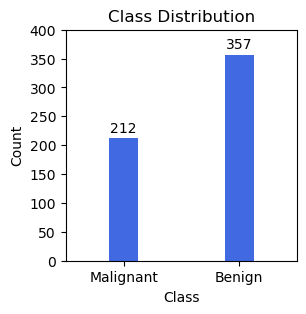

In [109]:
classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(3,3))
bars = plt.bar(classes, counts, width=0.25, color='royalblue')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.xlim([-0.5,1.5])
plt.ylim([0,400])
aspect_square(plt.gca())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is slightly imbalanced, with more benign than malignant samples.  
However, the imbalance is not severe, so standard evaluation metrics remain appropriate without requiring special handling.

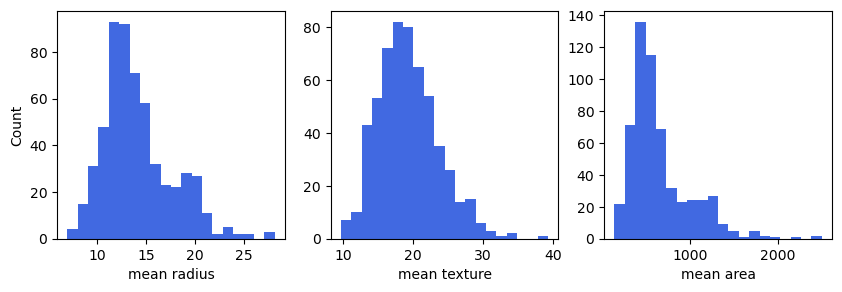

In [104]:
important_features = ["mean radius", "mean texture", "mean area"]

f, ax = plt.subplots(1,3,figsize=(10,3))
for i,feature in enumerate(important_features):
    ax[i].hist(X[feature], bins=20, color='royalblue')
    ax[i].set_xlabel(feature)
    aspect_square(ax[i])
    if i==0:
        ax[i].set_ylabel('Count')
plt.show()

The selected features show diverse distributions, with some skewness and long tails, particularly for mean area.  
This suggests that feature scaling may be beneficial for models sensitive to feature magnitude, such as logistic regression.

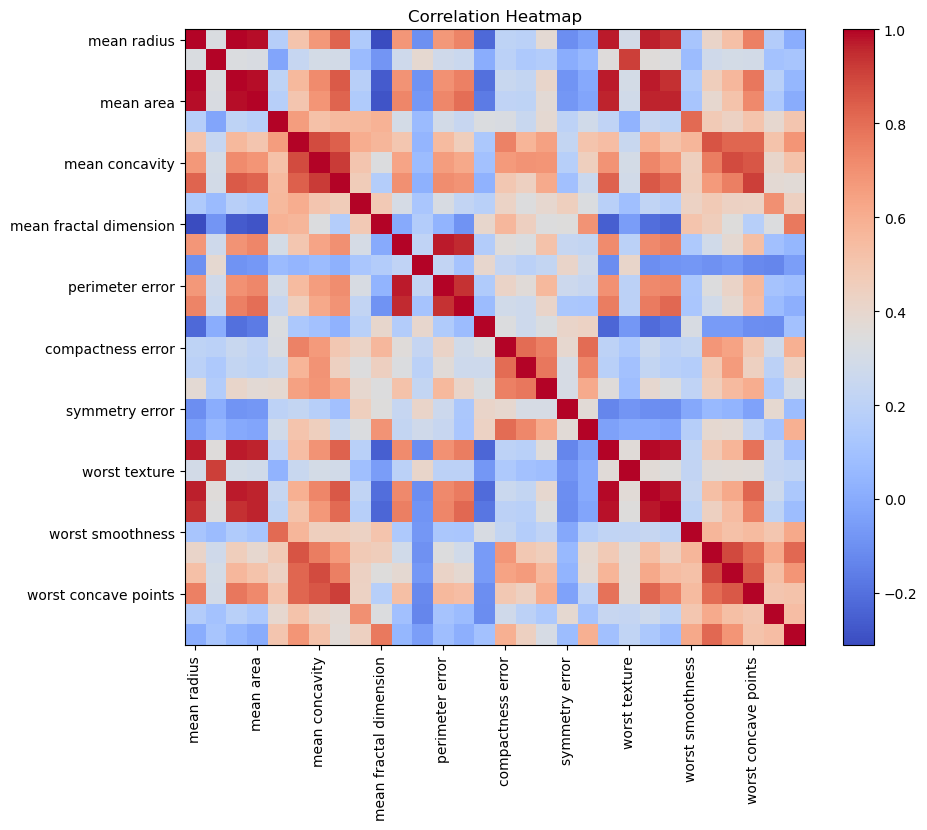

In [93]:
corr = X.corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

ticks = range(0, len(corr.columns), 3)
plt.xticks(ticks, corr.columns[ticks], rotation=90)
plt.yticks(ticks, corr.columns[ticks])

plt.title("Correlation Heatmap")
plt.show()

Several features are highly correlated, indicating redundancy in the dataset.  
This is expected, as many variables describe related physical properties of tumors.  
Tree-based models are less sensitive to this, while linear models may be affected by multicollinearity.

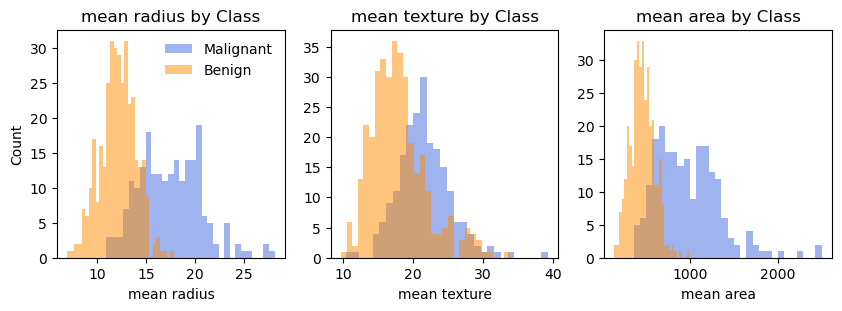

In [94]:
f, ax = plt.subplots(1,3,figsize=(10,3))

for i, feature in enumerate(important_features):
    ax[i].hist(X[y == 0][feature], bins=30, alpha=0.5, label="Malignant", color='royalblue')
    ax[i].hist(X[y == 1][feature], bins=30, alpha=0.5, label="Benign", color='darkorange')
    ax[i].set_title(f"{feature} by Class")
    ax[i].set_xlabel(feature)
    aspect_square(ax[i])
    if i==0:
        ax[i].legend(frameon=False)
        ax[i].set_ylabel("Count")
plt.show()

The distributions of key features differ noticeably between malignant and benign cases.  
Malignant tumors tend to have larger values (e.g., radius and area), showing clear separation between the classes.  
This suggests that these features are strong predictors and that the classification task is relatively well-structured.

### Summary of EDA

Overall, the dataset appears well-suited for classification.  
There is moderate class imbalance, strong feature correlations, and clear differences between classes for several variables.  
These observations suggest that both simple and ensemble models should perform well on this task.

### Train / Validation / Test Split

The dataset is split into training, validation, and test sets.

- **Training set (70%)**: used to train the models  
- **Validation set (15%)**: used for model selection and comparison  
- **Test set (15%)**: used for final evaluation  

Stratified sampling is applied to preserve the original class distribution across all splits.

In [106]:
from sklearn.model_selection import train_test_split

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

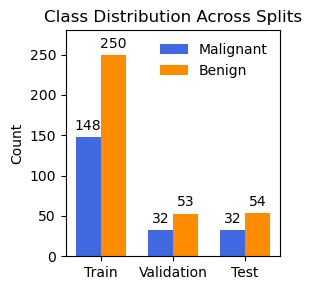

In [118]:
labels = ["Train", "Validation", "Test"]
datasets = [y_train, y_val, y_test]

malignant_counts = []
benign_counts = []

for y_set in datasets:
    classes, counts = np.unique(y_set, return_counts=True)
    malignant_counts.append(counts[0])
    benign_counts.append(counts[1])

x = np.arange(len(labels))

plt.figure(figsize=(3,3))

bars = plt.bar(x - 0.175, malignant_counts, width=0.35, label="Malignant", color='royalblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

bars = plt.bar(x + 0.175, benign_counts, width=0.35, label="Benign", color='darkorange')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(x, labels)
plt.ylim(0,280)
plt.ylabel("Count")
plt.title("Class Distribution Across Splits")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The class distribution is consistent across all splits, indicating that stratified sampling preserved the original data proportions.

This is important to ensure that performance metrics are comparable across training, validation, and test sets, and that the model is not evaluated on a distribution different from what it was trained on.

### Evaluation Metrics

To evaluate model performance, we use the following metrics:

- **Accuracy**: overall proportion of correct predictions  
- **Precision**: proportion of predicted positive cases that are correct  
- **Recall**: proportion of actual positive cases that are correctly identified  
- **ROC-AUC**: measures the model’s ability to distinguish between classes across different thresholds  

These metrics provide a balanced view of model performance, especially in classification tasks.

In [180]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_prob_benign = model.predict_proba(X)[:, 1]

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, pos_label=0),
        "Recall": recall_score(y, y_pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y, y_prob_benign),
    }

### Model Training

We train and compare several classification models of increasing complexity:

- Logistic Regression (baseline linear model)
- Decision Tree (non-linear model)

These models allow us to observe differences in flexibility, overfitting, and generalization performance.

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [182]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [183]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_metrics = evaluate_model(model, X_train, y_train)
    val_metrics = evaluate_model(model, X_val, y_val)
    
    results[name] = {
        "Train Accuracy": train_metrics["Accuracy"],
        "Val Accuracy": val_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Val Precision": val_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Val Recall": val_metrics["Recall"],
        "Train ROC-AUC": train_metrics["ROC-AUC"],
        "Val ROC-AUC": val_metrics["ROC-AUC"],
    }

df = pd.DataFrame(results).T
df

,Train Accuracy,Val Accuracy,Train Precision,Val Precision,Train Recall,Val Recall,Train ROC-AUC,Val ROC-AUC
Logistic Regression,0.969849,0.976471,0.965753,0.968750,0.952703,0.96875,0.993757,0.998821
Decision Tree,1.000000,0.929412,1.000000,0.861111,1.000000,0.96875,1.000000,0.937205


### Model Comparison: Logistic Regression vs Decision Tree

Logistic Regression achieves similar performance on both training and validation sets across all metrics, including accuracy, precision, recall, and ROC-AUC. This consistency indicates strong generalization. Despite its simplicity, it performs very well on this dataset, suggesting that the underlying patterns are relatively easy to learn.

In contrast, the Decision Tree reaches perfect performance on the training set for all metrics, but shows consistently lower performance on the validation set. This gap across accuracy, precision, recall, and ROC-AUC clearly indicates overfitting, as the model is capturing noise and specific patterns in the training data rather than learning generalizable relationships.

The drop in validation precision is particularly notable, indicating that the Decision Tree produces more false positives on unseen data, making its predictions less reliable. While recall remains relatively high, this comes at the cost of reduced overall robustness.

These results highlight the trade-off between model complexity and generalization: simpler models tend to generalize better, while more flexible models are more prone to overfitting without proper regularization.

### Ensemble Models

We now extend the comparison to ensemble methods:

- Random Forest (bagging-based ensemble)
- Gradient Boosting (boosting-based ensemble)

These models aim to improve performance by combining multiple decision trees and reducing overfitting.

In [184]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models.update({
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
})

In [185]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_metrics = evaluate_model(model, X_train, y_train)
    val_metrics = evaluate_model(model, X_val, y_val)
    
    results[name] = {
        "Train Accuracy": train_metrics["Accuracy"],
        "Val Accuracy": val_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Val Precision": val_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Val Recall": val_metrics["Recall"],
        "Train ROC-AUC": train_metrics["ROC-AUC"],
        "Val ROC-AUC": val_metrics["ROC-AUC"],
    }

df = pd.DataFrame(results).T
df

,Train Accuracy,Val Accuracy,Train Precision,Val Precision,Train Recall,Val Recall,Train ROC-AUC,Val ROC-AUC
Logistic Regression,0.969849,0.976471,0.965753,0.968750,0.952703,0.96875,0.993757,0.998821
Decision Tree,1.000000,0.929412,1.000000,0.861111,1.000000,0.96875,1.000000,0.937205
Random Forest,1.000000,0.988235,1.000000,0.969697,1.000000,1.00000,1.000000,0.999410
Gradient Boosting,1.000000,0.976471,1.000000,0.968750,1.000000,0.96875,1.000000,0.999410


### Ensemble Model Comparison

The ensemble models significantly improve upon the single Decision Tree.

Random Forest achieves the best validation performance across most metrics, including accuracy, recall, and ROC-AUC. Notably, it reaches perfect recall on the validation set, indicating that it successfully identifies all positive cases. This demonstrates how bagging reduces overfitting by averaging multiple decision trees.

Gradient Boosting also performs strongly, with high accuracy and ROC-AUC. However, it does not outperform Random Forest in this case, likely due to the simplicity of the dataset and the use of default hyperparameters.

Logistic Regression remains a strong baseline, showing stable and consistent performance across all metrics. This suggests that the dataset is relatively easy to classify and does not require highly complex models.

Overall, ensemble methods provide the best balance between flexibility and generalization, with Random Forest achieving the strongest performance.

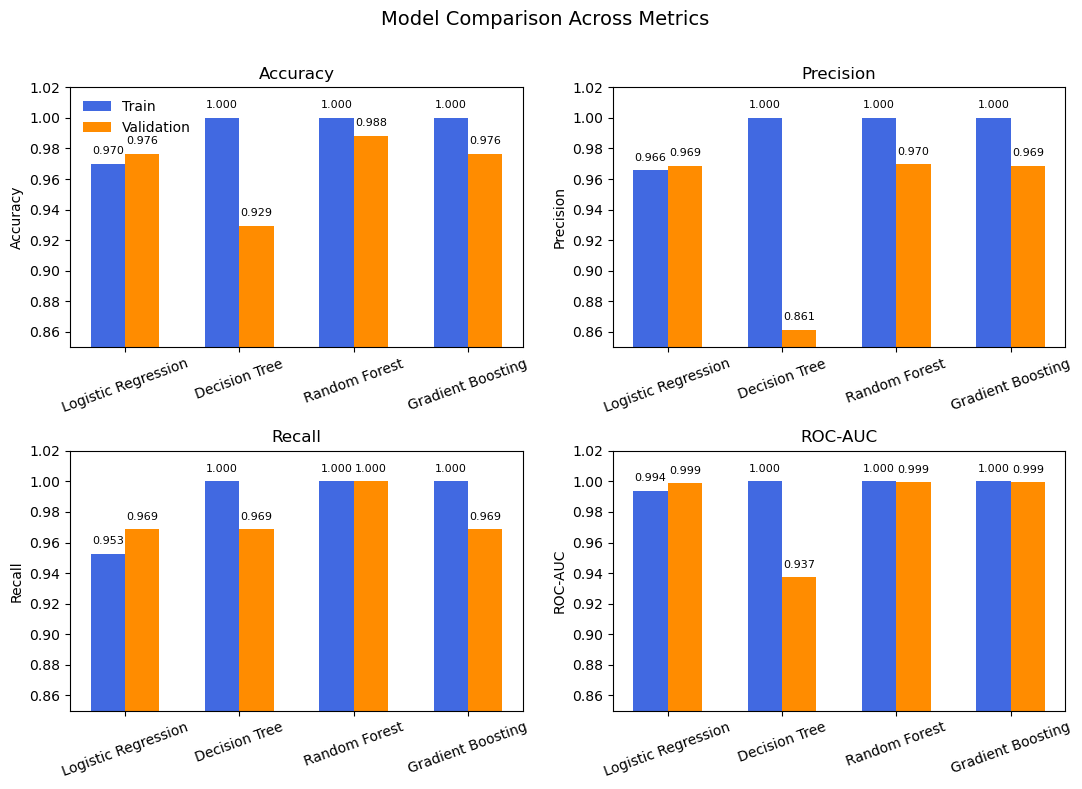

In [189]:
import numpy as np
import matplotlib.pyplot as plt

model_names = df.index.tolist()
x = np.arange(len(model_names))

metrics = ["Accuracy", "Precision", "Recall", "ROC-AUC"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    train_values = df[f"Train {metric}"].values
    val_values = df[f"Val {metric}"].values

    # Train bars
    bars = ax.bar(
        x - 0.15,
        train_values,
        width=0.3,
        label="Train",
        color="royalblue"
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Validation bars
    bars = ax.bar(
        x + 0.15,
        val_values,
        width=0.3,
        label="Validation",
        color="darkorange"
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20)
    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel(metric)
    ax.set_title(metric)

# show legend only once
axes[0].legend(frameon=False)

plt.suptitle("Model Comparison Across Metrics", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Model Comparison Across Metrics

The comparison across accuracy, precision, recall, and ROC-AUC provides a comprehensive view of model performance.

Logistic Regression shows consistent performance across all metrics, with minimal difference between training and validation sets, indicating strong generalization.

The Decision Tree exhibits clear overfitting, with perfect training performance but significantly lower validation scores across all metrics. The drop in precision is particularly notable, highlighting an increase in false positive predictions.

Random Forest achieves the best overall performance, with the highest validation accuracy and perfect recall. This indicates that it successfully identifies all positive cases while maintaining strong overall accuracy.

Gradient Boosting also performs well, with high scores across all metrics, although it does not outperform Random Forest in this case.

Overall, the results demonstrate how ensemble methods improve generalization and provide more robust performance compared to a single decision tree.

### Model Evaluation

We further evaluate model performance using:

- Cross-validation to assess stability  
- ROC curves to compare classification performance across thresholds  
- Confusion matrices to analyze prediction errors  

These tools provide deeper insight beyond simple accuracy metrics.

In [190]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring="roc_auc")
    cv_results[name] = scores.mean()

cv_df = pd.Series(cv_results)
cv_df

Logistic Regression    0.990114
Decision Tree          0.916429
Random Forest          0.985867
Gradient Boosting      0.987467
dtype: float64

### Cross-Validation

Cross-validation results confirm that Logistic Regression and ensemble models achieve consistently high performance across different folds.

The Decision Tree shows significantly lower performance, indicating that its behavior is unstable and sensitive to the training data.

Overall, the results demonstrate that simpler models and ensemble methods are more robust, while single decision trees tend to overfit.

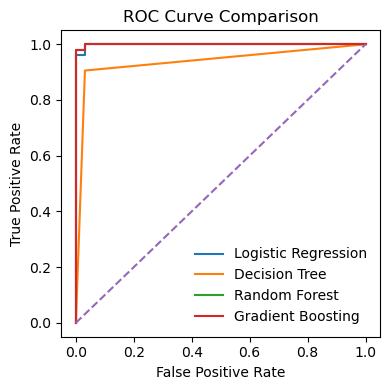

In [161]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(4,4))

for name, model in models.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### ROC Curve Analysis

All models achieve high ROC-AUC values, indicating strong ability to distinguish between malignant and benign cases.

Logistic Regression, Random Forest, and Gradient Boosting show very similar performance, with curves close to the top-left corner.

The Decision Tree performs slightly worse, confirming its tendency to overfit and generalize less effectively.

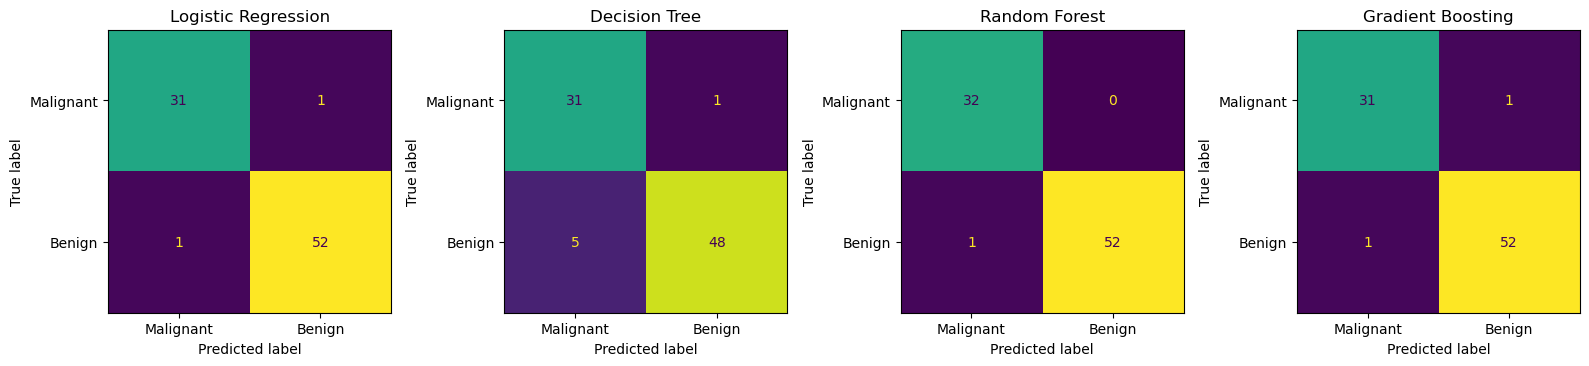

In [193]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cms = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    cms.append(cm)

vmax = max(cm.max() for cm in cms)

fig, axes = plt.subplots(1, len(models), figsize=(16, 4))

for ax, (name, model), cm in zip(axes, models.items(), cms):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="viridis")
    disp.im_.set_clim(0, vmax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrices reveal clear differences between models.

Logistic Regression performs well, with only one false negative and one false positive, indicating balanced and reliable predictions.

The Decision Tree shows a higher number of false positives, confirming its tendency to overfit and produce less stable predictions.

Random Forest achieves the best performance, with zero false negatives and only one false positive. This means it correctly identifies all malignant cases while maintaining high overall accuracy.

Gradient Boosting performs similarly to Logistic Regression, with a small number of errors and strong overall performance.

These results highlight the advantage of ensemble methods, particularly Random Forest, in reducing critical errors and improving robustness.

### Final Evaluation on Test Set

After selecting the best-performing models based on validation metrics and cross-validation, we evaluate their performance on a held-out test set.

The test set is strictly separated from the training and validation data and is used only once for final evaluation. This ensures an unbiased estimate of how the models perform on completely unseen data.

No further tuning or model adjustments are performed at this stage, allowing for a fair comparison of model generalization.

This final evaluation confirms whether the conclusions drawn during validation hold in a real-world setting.

In [194]:
test_results = {}

for name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    test_results[name] = metrics

test_df = pd.DataFrame(test_results).T
test_df

,Accuracy,Precision,Recall,ROC-AUC
Logistic Regression,0.918605,0.962963,0.81250,0.979167
Decision Tree,0.906977,0.928571,0.81250,0.887731
Random Forest,0.883721,0.866667,0.81250,0.980903
Gradient Boosting,0.918605,0.931034,0.84375,0.975694


### Test Set Results

The test set evaluation reveals some differences compared to the validation results.

Logistic Regression and Gradient Boosting achieve the highest accuracy, while Random Forest shows a noticeable drop in performance, indicating that it does not generalize as well as expected.

Gradient Boosting achieves the highest recall, making it more effective at identifying malignant cases, which is particularly important in a medical context.

Although Random Forest performed best on the validation set, its lower performance on the test set highlights the importance of evaluating models on completely unseen data.

Overall, Gradient Boosting provides the best balance between performance and reliability on the test set.

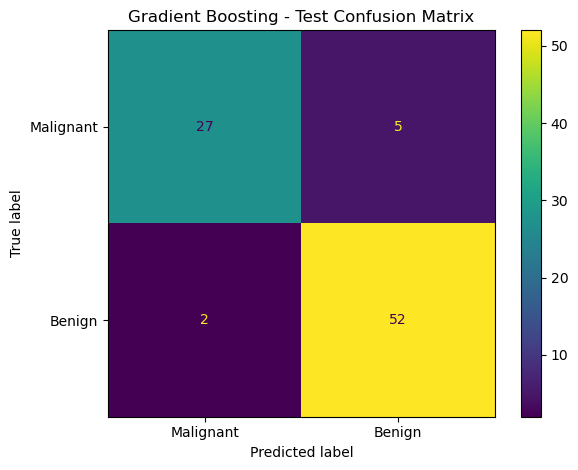

In [195]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    models["Gradient Boosting"],
    X_test,
    y_test,
    display_labels=["Malignant", "Benign"]
)

plt.title("Gradient Boosting - Test Confusion Matrix")
plt.tight_layout()
plt.show()

### Final Model Evaluation

Based on validation and test set performance, **Gradient Boosting** is selected as the final model.

While Random Forest achieved the best results on the validation set, its performance dropped noticeably on the test set. This suggests that its validation performance may have been slightly optimistic and highlights the importance of evaluating models on a fully unseen dataset.

Gradient Boosting, on the other hand, demonstrates more consistent generalization, maintaining strong performance across both validation and test sets.

The confusion matrix on the test set shows:
- A low number of false positives, indicating reliable predictions
- A small number of false negatives, meaning most malignant cases are correctly identified

In a medical context, recall is particularly important, as failing to detect malignant cases can have serious consequences. Gradient Boosting achieves the highest recall among the evaluated models, making it the most appropriate choice for this task.

Overall, Gradient Boosting provides the best balance between:
- Accuracy
- Precision
- Recall

This final evaluation highlights two key insights:
- Strong validation performance does not always guarantee strong test performance
- Model selection should prioritize generalization and task-specific metrics, not just overall accuracy